# Generative Adversarial Networks (GANs) Examples

This notebook demonstrates different types of Generative Adversarial Networks (GANs) on various datasets. It covers basic GAN implementation, Conditional GANs (cGANs), and GANs for tabular data generation.

In [ ]:
!pip install torchvision

## Basic GAN for MNIST Digit Generation

This section implements a basic Generative Adversarial Network (GAN) to generate synthetic handwritten digits similar to the MNIST dataset. It consists of a Generator network that creates fake images and a Discriminator network that distinguishes between real and fake images.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Preprocess the Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
data_loader = DataLoader(dataset, batch_size=128, shuffle=True)

### Step 1: Data Preprocessing and Loading

We load the MNIST dataset, apply transformations to convert images to tensors and normalize their pixel values to a range of `[-1, 1]`. The data is then loaded into a `DataLoader` for batch processing during training.

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 28 * 28),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x).view(-1, 1, 28, 28)

### Step 2: Define Generator and Discriminator Models

**Generator Network:**
- Takes a random noise vector (`z`) as input (latent space).
- Upsamples this noise through several fully connected layers.
- Uses `ReLU` activation for hidden layers and `Tanh` for the output layer to scale pixel values to `[-1, 1]`.
- Reshapes the output into a 2D image (28x28 for MNIST).

**Discriminator Network:**
- Takes a 2D image (real or fake) as input.
- Flattens the image and processes it through several fully connected layers.
- Uses `LeakyReLU` activation to prevent 'dying ReLU' problems and `Sigmoid` for the output layer to produce a probability (0 for fake, 1 for real).

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(28 * 28, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x.view(-1, 28 * 28))


In [ ]:
# Initialize models
generator = Generator()
discriminator = Discriminator()


### Model Initialization, Loss Function, and Optimizers

- The `Generator` and `Discriminator` models are initialized.
- `BCELoss` (Binary Cross-Entropy Loss) is chosen as the criterion, which is commonly used in GANs for binary classification problems (real vs. fake).
- `Adam` optimizers are set up for both the generator and discriminator, with a learning rate of 0.0002.

In [ ]:
criterion = nn.BCELoss()
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002)
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002)

In [ ]:
# Step 3: Train the GAN
def train_gan(generator, discriminator, data_loader, epochs=50):
    for epoch in range(epochs):
        for i, (real_images, _) in enumerate(data_loader):
            batch_size = real_images.size(0)

            # Prepare real and fake labels
            real_labels = torch.ones(batch_size, 1)
            fake_labels = torch.zeros(batch_size, 1)

            # Train Discriminator
            real_images = real_images.view(batch_size, -1)
            outputs = discriminator(real_images)
            d_loss_real = criterion(outputs, real_labels)

            z = torch.randn(batch_size, 100)
            fake_images = generator(z)
            outputs = discriminator(fake_images.detach())
            d_loss_fake = criterion(outputs, fake_labels)

            d_loss = d_loss_real + d_loss_fake

            d_optimizer.zero_grad()
            d_loss.backward()
            d_optimizer.step()
            # Train Generator
            z = torch.randn(batch_size, 100)
            fake_images = generator(z)
            outputs = discriminator(fake_images)
            g_loss = criterion(outputs, real_labels)

            g_optimizer.zero_grad()
            g_loss.backward()
            g_optimizer.step()

        print(f"Epoch [{epoch+1}/{epochs}], d_loss: {d_loss.item():.4f}, g_loss: {g_loss.item():.4f}")

### Step 3: Training the GAN

The `train_gan` function implements the core training loop:
1. **Discriminator Training:**
   - Calculates loss for real images (should be classified as real).
   - Generates fake images from random noise using the generator.
   - Calculates loss for fake images (should be classified as fake).
   - Combines real and fake losses, performs backpropagation, and updates discriminator weights.
2. **Generator Training:**
   - Generates new fake images.
   - Calculates loss based on how well the discriminator is fooled (i.e., generator wants fake images to be classified as real).
   - Performs backpropagation and updates generator weights.

In [ ]:
# Train the GAN
train_gan(generator, discriminator, data_loader, epochs=5)

Epoch [1/5], d_loss: 0.0024, g_loss: 7.3704
Epoch [2/5], d_loss: 0.0000, g_loss: 12.4891
Epoch [3/5], d_loss: 0.1128, g_loss: 12.5425
Epoch [4/5], d_loss: 0.5339, g_loss: 7.2539
Epoch [5/5], d_loss: 0.6267, g_loss: 2.2269


The GAN is trained for 5 epochs. The printed losses show how well each network is performing.

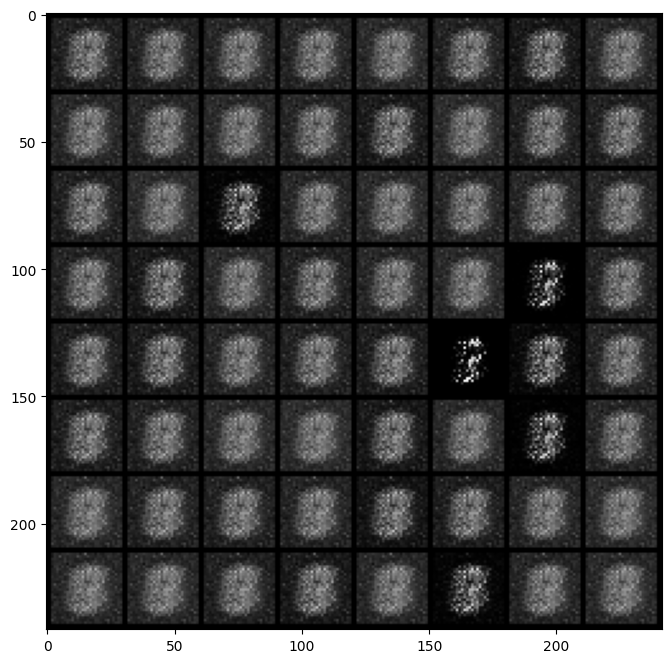

In [ ]:
# Step 4: Generate Images
with torch.no_grad():
    z = torch.randn(64, 100)
    generated_images = generator(z).view(-1, 1, 28, 28).cpu()

    # Display the images
    grid = np.transpose(utils.make_grid(generated_images, normalize=True), (1, 2, 0))
    plt.figure(figsize=(8, 8))
    plt.imshow(grid, cmap='gray')
    plt.show()

### Step 4: Generate and Visualize Images

After training, the generator is used to produce new images from random noise. These generated images are then displayed to visually assess the quality of the GAN's output.

## Conditional GAN (cGAN) for Image-to-Edge Translation on CIFAR-10

This section implements a Conditional GAN (cGAN) to translate grayscale images into their corresponding edge maps. Unlike a traditional GAN, a cGAN takes additional conditioning information (in this case, the grayscale image itself) to guide the image generation process. Here, the goal is to generate edge maps from input grayscale images, rather than just random images.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Preprocess the Dataset
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

cifar10_dataset = datasets.CIFAR10(root="./data", train=True, transform=transform, download=True)

# Generate edge maps using Sobel filter
import cv2

def generate_edge_maps(images):
    edge_maps = []
    for img in images:
        img_np = img.numpy().squeeze()  # Convert tensor to numpy
        edges = cv2.Canny((img_np * 255).astype(np.uint8), 100, 200)  # Edge detection
        edge_maps.append(edges / 255.0 * 2 - 1)  # Normalize to [-1, 1]
    return torch.tensor(edge_maps).unsqueeze(1)

class EdgeDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __getitem__(self, index):
        image, _ = self.dataset[index]
        edge_map = generate_edge_maps([image])[0]
        return image, edge_map

    def __len__(self):
        return len(self.dataset)

data_loader = DataLoader(EdgeDataset(cifar10_dataset), batch_size=128, shuffle=True)

100%|██████████| 170M/170M [00:18<00:00, 9.19MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data


### Step 1: Data Preprocessing, Edge Map Generation, and Dataset Creation

- **CIFAR-10 Dataset:** The CIFAR-10 dataset (which contains color images) is loaded and transformed into grayscale, then normalized.
- **Edge Map Generation (`generate_edge_maps`):** The `cv2.Canny` function is used to perform Canny edge detection on each grayscale image, creating ground-truth edge maps.
- **`EdgeDataset`:** A custom `Dataset` is created to pair the original grayscale images with their generated edge maps.
- **`DataLoader`:** The dataset is loaded into a `DataLoader` for batch processing during training.

In [ ]:
def generate_edge_maps(images):
    edge_maps = []
    for img in images:
        img_np = img.numpy().squeeze()  # Convert tensor to numpy
        edges = cv2.Canny((img_np * 255).astype(np.uint8), 100, 200)  # Edge detection
        edge_maps.append(edges / 255.0 * 2 - 1)  # Normalize to [-1, 1]
    return torch.tensor(edge_maps).unsqueeze(1).float()  # Ensure float type

This cell redefines the `generate_edge_maps` function to ensure the output tensor is of type `float` for compatibility with PyTorch models. The previous definition implicitly converted to `float` but explicitly casting ensures robustness.

In [ ]:
# Step 2: Build the cGAN
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(2, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# Initialize models
generator = Generator()
discriminator = Discriminator()

# Loss function and optimizers
criterion = nn.BCELoss()
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002)
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002)

### Step 2: Build the cGAN Generator and Discriminator Models

**Generator Network:**
- Uses convolutional layers (`Conv2d`) and transposed convolutional layers (`ConvTranspose2d`) for encoding and decoding.
- The generator aims to learn a mapping from input grayscale images to edge maps.
- `ReLU` activations are used, and `Tanh` for the final output to scale to `[-1, 1]`.

**Discriminator Network:**
- Takes *both* the grayscale image and an edge map (either real or fake) as input, concatenated along the channel dimension.
- Uses convolutional layers and `LeakyReLU` activations.
- The final layer is a fully connected layer with `Sigmoid` activation to classify the input pair as real (grayscale image with its true edge map) or fake (grayscale image with a generated edge map).

**Model Initialization, Loss Function, and Optimizers:**
- `Generator` and `Discriminator` models are initialized.
- `BCELoss` is used.
- `Adam` optimizers are set up with a learning rate of 0.0002.

In [ ]:
def train_cgan(generator, discriminator, data_loader, epochs=50):
    for epoch in range(epochs):
        for i, (grayscale_images, edge_maps) in enumerate(data_loader):
            # Ensure inputs are float
            grayscale_images, edge_maps = grayscale_images.float(), edge_maps.float()

            batch_size = grayscale_images.size(0)

            # Prepare real and fake labels
            real_labels = torch.ones(batch_size, 1).float()
            fake_labels = torch.zeros(batch_size, 1).float()

            # Train Discriminator
            real_pairs = torch.cat((grayscale_images, edge_maps), dim=1)
            outputs = discriminator(real_pairs)
            d_loss_real = criterion(outputs, real_labels)

            fake_edges = generator(grayscale_images)
            fake_pairs = torch.cat((grayscale_images, fake_edges), dim=1)
            outputs = discriminator(fake_pairs.detach())
            d_loss_fake = criterion(outputs, fake_labels)

            d_loss = d_loss_real + d_loss_fake

            d_optimizer.zero_grad()
            d_loss.backward()
            d_optimizer.step()

            # Train Generator
            fake_edges = generator(grayscale_images)
            fake_pairs = torch.cat((grayscale_images, fake_edges), dim=1)
            outputs = discriminator(fake_pairs)
            g_loss = criterion(outputs, real_labels)

            g_optimizer.zero_grad()
            g_loss.backward()
            g_optimizer.step()

        print(f"Epoch [{epoch+1}/{epochs}], d_loss: {d_loss.item():.4f}, g_loss: {g_loss.item():.4f}")


### Step 3: Training the cGAN

The `train_cgan` function follows a similar logic to the basic GAN, but with conditioning:
1. **Discriminator Training:**
   - Receives pairs of `(grayscale_image, real_edge_map)` and `(grayscale_image, fake_edge_map)`.
   - Learns to distinguish between real and fake pairs.
2. **Generator Training:**
   - Generates `fake_edge_map` from `grayscale_image`.
   - Tries to fool the discriminator into classifying `(grayscale_image, fake_edge_map)` as a real pair.

In [ ]:
generator = generator.float()
discriminator = discriminator.float()


This step ensures that both the generator and discriminator models are cast to float type, which is necessary for consistent tensor operations when inputs are also float. This helps prevent potential type mismatch errors during training.

In [ ]:
# Train the cGAN
train_cgan(generator, discriminator, data_loader, epochs=5)

<ipython-input-2-73bb14ed57d5>:7: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  return torch.tensor(edge_maps).unsqueeze(1).float()  # Ensure float type


Epoch [1/5], d_loss: 0.0191, g_loss: 9.0464
Epoch [2/5], d_loss: 0.0010, g_loss: 11.9156
Epoch [3/5], d_loss: 0.0002, g_loss: 11.9172
Epoch [4/5], d_loss: 0.0006, g_loss: 20.1840
Epoch [5/5], d_loss: 0.0002, g_loss: 29.4721


The cGAN is trained for 5 epochs. The `UserWarning` regarding tensor creation from numpy arrays is due to the `generate_edge_maps` function being called iteratively during data loading, which is less efficient but doesn't prevent the code from running.

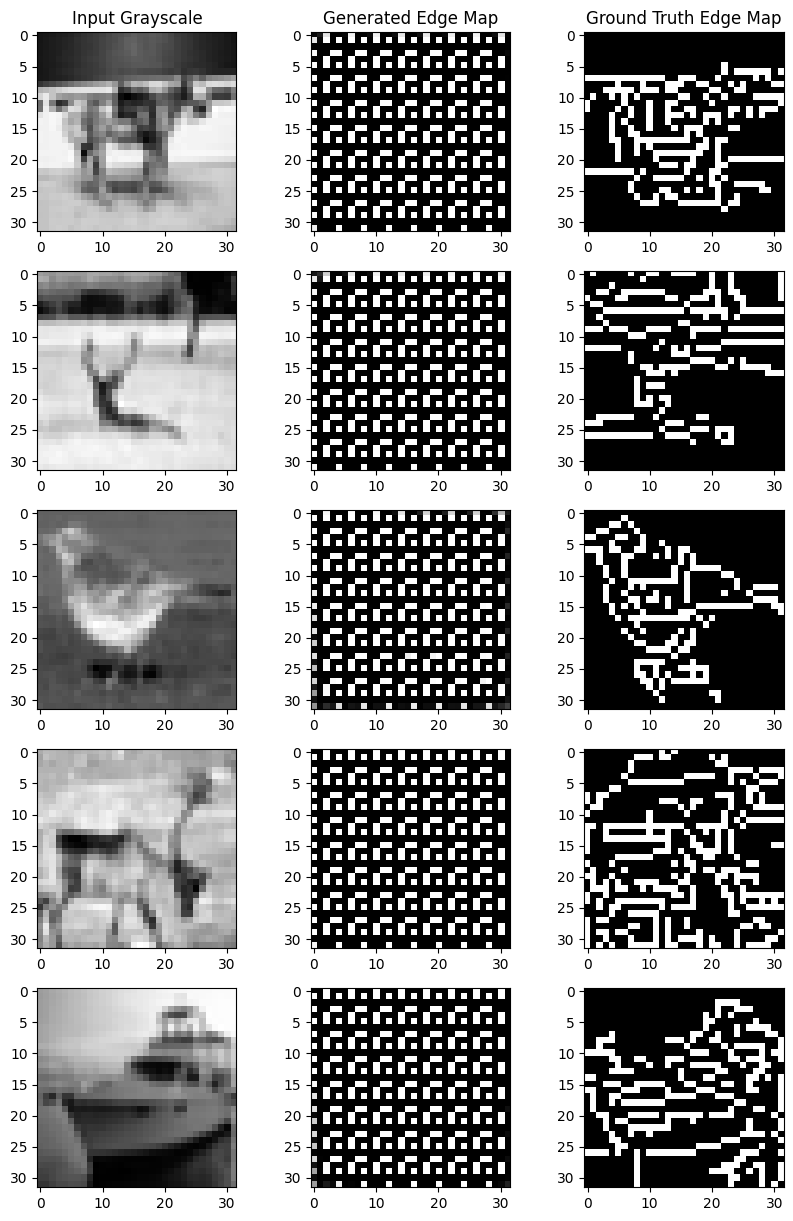

In [ ]:
# Step 4: Translate Images
with torch.no_grad():
    for i, (grayscale_images, _) in enumerate(data_loader):
        if i == 1: break  # Take only the first batch for visualization
        fake_edges = generator(grayscale_images).cpu()

        # Display side-by-side comparisons
        fig, axes = plt.subplots(5, 3, figsize=(10, 15))
        for j in range(5):
            axes[j, 0].imshow(grayscale_images[j, 0], cmap='gray')
            axes[j, 1].imshow(fake_edges[j, 0], cmap='gray')
            axes[j, 2].imshow(generate_edge_maps([grayscale_images[j]])[0, 0], cmap='gray')

        axes[0, 0].set_title('Input Grayscale')
        axes[0, 1].set_title('Generated Edge Map')
        axes[0, 2].set_title('Ground Truth Edge Map')
        plt.show()

# Step 6 & 7: Evaluate and Report
# Add metrics like Mean Squared Error or FID here.

### Step 4: Translate and Visualize Images

After training, the generator is used to translate new grayscale images into their predicted edge maps. These are then visualized alongside the original grayscale images and their ground-truth edge maps for comparison.

## GAN for Tabular Data Generation on UCI Adult Dataset

This section demonstrates how to use a GAN to generate synthetic tabular data. The goal is to produce new data samples that statistically resemble a real-world dataset (UCI Adult dataset) without directly copying it. This can be useful for data augmentation, privacy-preserving data sharing, or balancing imbalanced datasets.

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

# Step 1: Preprocess the Dataset
# Load dataset (UCI Adult dataset as an example)
data = fetch_openml(name="adult", version=2, as_frame=True)
data = data.frame

# Check for the correct column name for income
# The column might be named 'class' instead of 'income'
income_column = 'class'  # Or 'income' if it exists

# Binary classification (income >50K or <=50K)
data = data.dropna()
# Use the identified income column here
data['income'] = data[income_column].apply(lambda x: 1 if x == '>50K' else 0)

# Separate features and labels
X = data.drop('income', axis=1)  # Drop the newly created 'income' column
y = data['income']

# One-hot encode categorical variables
categorical_cols = X.select_dtypes(include=['object']).columns
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_cats = encoder.fit_transform(X[categorical_cols])
encoded_cat_df = pd.DataFrame(encoded_cats, columns=encoder.get_feature_names_out())

# Normalize numerical features
numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns
scaler = MinMaxScaler()
numerical_features = scaler.fit_transform(X[numerical_cols])
numerical_df = pd.DataFrame(numerical_features, columns=numerical_cols)

# Combine preprocessed features
X_processed = pd.concat([numerical_df, encoded_cat_df], axis=1)
X_processed = X_processed.to_numpy()
y = y.to_numpy()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

### Step 1: Data Preprocessing and Loading

- **Load Dataset:** The UCI Adult dataset is fetched, which contains various demographic and employment-related features.
- **Handle Missing Values:** Rows with missing values are dropped.
- **Target Variable:** The 'income' (or 'class') column is converted into a binary target (0 for `<=50K`, 1 for `>50K`).
- **Feature Engineering:**
    - Categorical features are one-hot encoded.
    - Numerical features are normalized using `MinMaxScaler` to bring them into a common range.
- **Combine Features:** Processed numerical and one-hot encoded categorical features are combined.
- **Train-Test Split:** The dataset is split into training and testing sets.

In [ ]:
# Step 2: Build the GAN
input_dim = X_train.shape[1]

class Generator(nn.Module):
    def __init__(self, noise_dim, output_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# Initialize models
generator = Generator(noise_dim=100, output_dim=input_dim)
discriminator = Discriminator(input_dim=input_dim)

# Loss function and optimizers
criterion = nn.BCELoss()
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002)
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002)


### Step 2: Build the GAN Generator and Discriminator Models for Tabular Data

**Generator Network:**
- Takes a random noise vector as input.
- Uses fully connected layers and `ReLU` activations.
- The output layer uses `Sigmoid` activation to ensure that the generated values are within a `[0, 1]` range, consistent with the normalized and one-hot encoded real data.

**Discriminator Network:**
- Takes a flattened tabular data sample as input.
- Uses fully connected layers and `LeakyReLU` activations.
- The final layer uses `Sigmoid` activation to output a probability of the input data being real or fake.

**Model Initialization, Loss Function, and Optimizers:**
- `Generator` and `Discriminator` models are initialized based on the processed data's input dimension.
- `BCELoss` is used.
- `Adam` optimizers are set up with a learning rate of 0.0002.

In [ ]:
# Step 3: Train the GAN
def train_gan(generator, discriminator, X_train, epochs=50, batch_size=64):
    real_labels = torch.ones(batch_size, 1)
    fake_labels = torch.zeros(batch_size, 1)

    for epoch in range(epochs):
        for i in range(0, len(X_train), batch_size):
            real_data = torch.tensor(X_train[i:i+batch_size], dtype=torch.float32)

            # Train Discriminator
            outputs = discriminator(real_data)
            d_loss_real = criterion(outputs, real_labels[:len(real_data)])

            noise = torch.randn(len(real_data), 100)
            fake_data = generator(noise)
            outputs = discriminator(fake_data.detach())
            d_loss_fake = criterion(outputs, fake_labels[:len(real_data)])

            d_loss = d_loss_real + d_loss_fake

            d_optimizer.zero_grad()
            d_loss.backward()
            d_optimizer.step()

            # Train Generator
            noise = torch.randn(len(real_data), 100)
            fake_data = generator(noise)
            outputs = discriminator(fake_data)
            g_loss = criterion(outputs, real_labels[:len(real_data)])

            g_optimizer.zero_grad()
            g_loss.backward()
            g_optimizer.step()

        print(f"Epoch [{epoch+1}/{epochs}], d_loss: {d_loss.item():.4f}, g_loss: {g_loss.item():.4f}")

train_gan(generator, discriminator, X_train, epochs=10, batch_size=64)


Epoch [1/10], d_loss: 1.4702, g_loss: 0.6984
Epoch [2/10], d_loss: 1.3293, g_loss: 0.8041
Epoch [3/10], d_loss: 1.3551, g_loss: 0.8589
Epoch [4/10], d_loss: 1.1593, g_loss: 0.8920
Epoch [5/10], d_loss: 1.2356, g_loss: 0.8852
Epoch [6/10], d_loss: 1.2984, g_loss: 0.8791
Epoch [7/10], d_loss: 1.1915, g_loss: 0.9568
Epoch [8/10], d_loss: 1.2516, g_loss: 0.8066
Epoch [9/10], d_loss: 1.2927, g_loss: 0.8625
Epoch [10/10], d_loss: 1.4359, g_loss: 0.7805


### Step 3: Training the GAN for Tabular Data

The `train_gan` function for tabular data follows the standard GAN training procedure:
1. **Discriminator Training:**
   - Compares the discriminator's output for real data samples from `X_train` against `real_labels`.
   - Generates fake data using the generator from random noise and compares the discriminator's output against `fake_labels`.
   - Updates the discriminator based on the combined loss.
2. **Generator Training:**
   - Generates fake data.
   - Tries to fool the discriminator into classifying its generated data as real.
   - Updates the generator based on this loss.

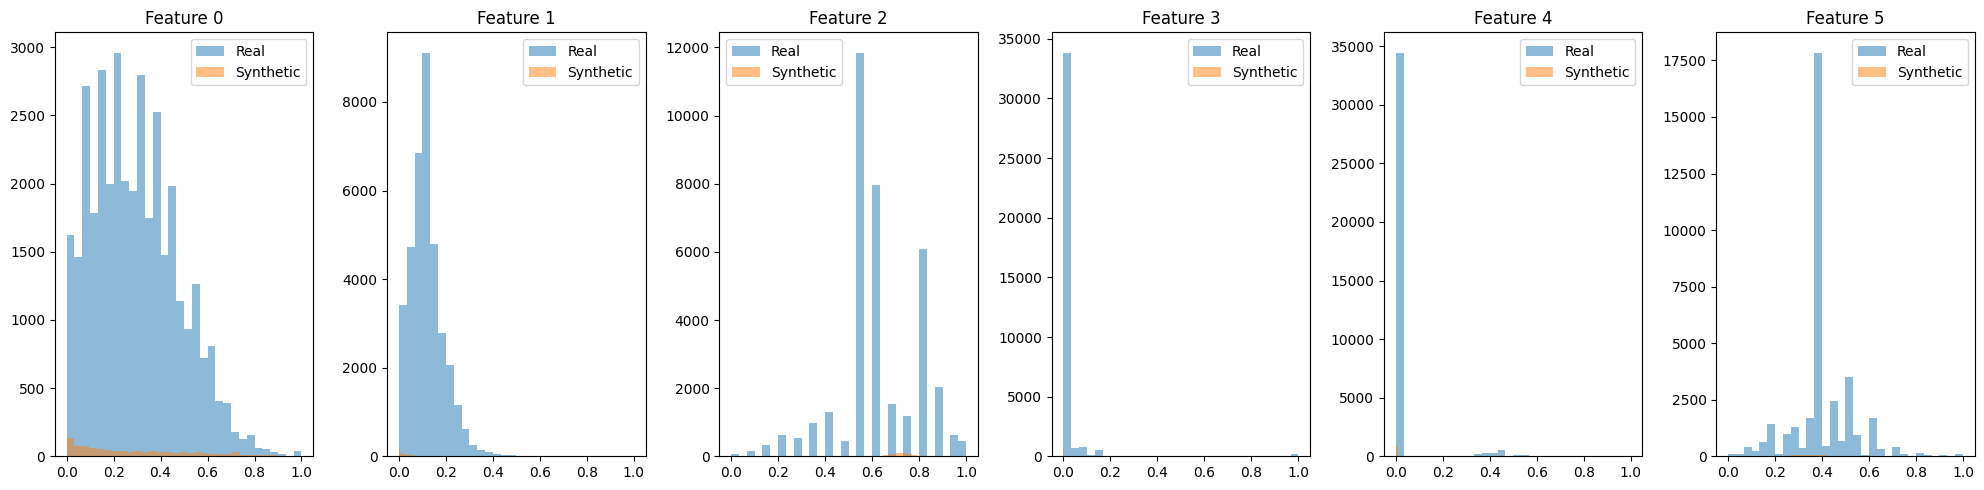

In [ ]:
# Step 4: Generate Tabular Data
noise = torch.randn(1000, 100)
synthetic_data = generator(noise).detach().numpy()

# Step 5: Evaluate
# Compare distributions
fig, axes = plt.subplots(1, input_dim, figsize=(20, 5))
for i in range(input_dim):
    axes[i].hist(X_train[:, i], bins=30, alpha=0.5, label='Real')
    axes[i].hist(synthetic_data[:, i], bins=30, alpha=0.5, label='Synthetic')
    axes[i].set_title(f"Feature {i}")
    axes[i].legend()
plt.tight_layout()
plt.show()

### Step 4 & 5: Generate and Evaluate Tabular Data

- **Synthetic Data Generation:** The trained generator creates 1000 new synthetic data samples from random noise.
- **Evaluation (Distribution Comparison):** Histograms are used to visualize and compare the distribution of each feature in the real training data (`X_train`) against the generated synthetic data. This helps assess how well the GAN has learned the underlying data distribution.